# Deep Learning for Image Inpainting

Image inpainting reconstructs missing regions of an image using the visible surrounding content. This project will compare a lightweight **U-Net**, a lightweight **Vision Transformer (ViT)**, and their **weighted ensemble**.

## Phase 1: Dataset preparation

This phase loads original images, creates reproducible data splits, and checks the data. Run the cells in order in Google Colab. Masking and models will be added in later phases.

In [ ]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

SEED = 42
IMAGE_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 2
TRAIN_FRACTION = 0.8
# Download into Colab's temporary runtime storage when this cell is run there.
DATA_ROOT = Path('/content/data') if Path('/content').is_dir() else Path('data')

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Dataset location: {DATA_ROOT.resolve()}')

## Oxford-IIIT Pet Dataset and splits

Oxford-IIIT Pet contains photographs of cats and dogs from 37 pet categories. We use the photographs for reconstruction; category labels returned by torchvision are not needed for inpainting.

The **official test split remains untouched** and reserved for final evaluation. We split only the official **trainval** split into **80% training / 20% validation**, using a fixed seed. Both future models will use these same subsets.

Images are loaded as RGB by torchvision, resized to **128 × 128**, and converted to floating-point tensors in **[0, 1]**. No ImageNet mean/std normalization is applied. The first run downloads the dataset into the runtime's data folder and may take a few minutes.

In [ ]:
image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

trainval_dataset = datasets.OxfordIIITPet(
    root=DATA_ROOT,
    split='trainval',
    target_types='category',
    transform=image_transform,
    download=True,
)
test_dataset = datasets.OxfordIIITPet(
    root=DATA_ROOT,
    split='test',
    target_types='category',
    transform=image_transform,
    download=True,
)

train_size = int(TRAIN_FRACTION * len(trainval_dataset))
val_size = len(trainval_dataset) - train_size
train_dataset, val_dataset = random_split(
    trainval_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    generator=torch.Generator().manual_seed(SEED),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

In [ ]:
print(f'Official trainval: {len(trainval_dataset):,}')
print(f'Training:         {len(train_dataset):,}')
print(f'Validation:       {len(val_dataset):,}')
print(f'Official test:     {len(test_dataset):,}')

# Check that training and validation partition trainval without overlap.
train_indices = set(train_dataset.indices)
val_indices = set(val_dataset.indices)
assert len(train_indices) == train_size > 0
assert len(val_indices) == val_size > 0
assert train_indices.isdisjoint(val_indices)
assert train_indices | val_indices == set(range(len(trainval_dataset)))
assert test_dataset is not trainval_dataset
assert len(test_dataset) > 0

# Verify that the same seed reproduces exactly the same split.
expected_indices = torch.randperm(
    len(trainval_dataset), generator=torch.Generator().manual_seed(SEED)
).tolist()
assert train_dataset.indices == expected_indices[:train_size]
assert val_dataset.indices == expected_indices[train_size:]

# Inspect a training batch only; do not iterate over the test set.
images, _ = next(iter(train_loader))
print(f'Batch shape: {list(images.shape)}')
print(f'Pixel range: [{images.min().item():.3f}, {images.max().item():.3f}]')
assert images.shape == (min(BATCH_SIZE, train_size), 3, IMAGE_SIZE, IMAGE_SIZE)
assert images.dtype == torch.float32
assert torch.isfinite(images).all().item()
assert 0.0 <= images.min().item() <= images.max().item() <= 1.0
print('All split and training-batch sanity checks passed.')

In [ ]:
# Display eight original training images from the checked batch.
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for index, ax in enumerate(axes.flat):
    ax.imshow(images[index].permute(1, 2, 0).numpy())
    ax.set_title(f'Training image {index + 1}')
    ax.axis('off')
fig.suptitle('Original training images (128 x 128)')
plt.tight_layout()
plt.show()

## Phase 2: Artificial rectangular masks

The **masked image is the model input**, and the **unchanged original image is the reconstruction target**. We use central or randomly positioned rectangular masks, with examples of sizes **24 x 24**, **32 x 32**, and **48 x 48**.

For each RGB image of shape `[3, H, W]`, the binary mask has shape `[1, H, W]`: **1 (True) marks missing pixels**, and **0 (False) marks visible pixels**. The same mask covers all three color channels. Missing pixels are filled with **0 (black)** in a new tensor, leaving the target unchanged. In the mask plots, white indicates the missing region.

Supplying a seed reproduces the random position for the same image dimensions and mask size. Use different seeds for different examples. These examples only verify masking; the training-mask mixture will be decided later.

In [ ]:
MASK_SIZES = [(24, 24), (32, 32), (48, 48)]
MASK_FILL_VALUE = 0.0


def make_rectangular_mask(image, mask_size=(32, 32), position='central', seed=None):
    """Return a boolean [1, H, W] mask: True means a missing pixel."""
    if image.ndim != 3 or image.shape[0] != 3:
        raise ValueError('Expected an RGB image with shape [3, H, W].')
    height, width = image.shape[-2:]
    mask_height, mask_width = mask_size
    if not (0 < mask_height <= height and 0 < mask_width <= width):
        raise ValueError('Mask dimensions must be positive and fit inside the image.')

    if position == 'central':
        top = (height - mask_height) // 2
        left = (width - mask_width) // 2
    elif position == 'random':
        # A local seeded generator does not reset the global random state.
        generator = None if seed is None else torch.Generator().manual_seed(seed)
        top = torch.randint(height - mask_height + 1, (1,), generator=generator).item()
        left = torch.randint(width - mask_width + 1, (1,), generator=generator).item()
    else:
        raise ValueError("position must be 'central' or 'random'.")

    mask = torch.zeros((1, height, width), dtype=torch.bool, device=image.device)
    mask[:, top:top + mask_height, left:left + mask_width] = True
    return mask


def apply_mask(image, mask):
    """Fill the hole in a new tensor; preserve the original image."""
    return image.masked_fill(mask, MASK_FILL_VALUE)

In [ ]:
# Use only training images from Phase 1; the test set stays untouched.
originals_before_masking = images.clone()
for position in ('central', 'random'):
    for mask_size in MASK_SIZES:
        target = images[0]
        mask = make_rectangular_mask(target, mask_size, position, seed=SEED)
        masked_image = apply_mask(target, mask)

        assert mask.shape == (1, IMAGE_SIZE, IMAGE_SIZE)
        assert mask.dtype == torch.bool
        assert masked_image.shape == target.shape
        # Count spatial pixels once, not once per RGB channel.
        assert mask.sum().item() == mask_size[0] * mask_size[1]
        missing_channels = mask.expand_as(target)
        assert torch.all(masked_image[missing_channels] == MASK_FILL_VALUE).item()
        assert torch.equal(masked_image[~missing_channels], target[~missing_channels])
        assert torch.equal(images, originals_before_masking)

        if position == 'central':
            top = (IMAGE_SIZE - mask_size[0]) // 2
            left = (IMAGE_SIZE - mask_size[1]) // 2
            assert mask[:, top:top + mask_size[0], left:left + mask_size[1]].all().item()
        else:
            repeated_mask = make_rectangular_mask(target, mask_size, position, seed=SEED)
            assert torch.equal(mask, repeated_mask)

        print(f'{position:7s} {mask_size}: {mask.sum().item()} missing pixels - passed')

print('All Phase 2 sanity checks passed; original targets are unchanged.')

In [ ]:
# Two figures, each with three training images and all three mask sizes.
# Reuse the same originals across figures for a direct position comparison.
for position in ('central', 'random'):
    fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    for row, mask_size in enumerate(MASK_SIZES):
        target = images[row]
        mask = make_rectangular_mask(target, mask_size, position, seed=SEED + row)
        masked_image = apply_mask(target, mask)

        axes[row, 0].imshow(target.permute(1, 2, 0).cpu().numpy())
        axes[row, 1].imshow(masked_image.permute(1, 2, 0).cpu().numpy())
        axes[row, 2].imshow(mask[0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[row, 0].set_title(f'Original (training image {row + 1})')
        axes[row, 1].set_title(f'Masked ({mask_size[0]} x {mask_size[1]})')
        axes[row, 2].set_title('Mask (white = missing)')
        for ax in axes[row]:
            ax.axis('off')

    fig.suptitle(f'{position.capitalize()} rectangular masks')
    plt.tight_layout()
    plt.show()

assert torch.equal(images, originals_before_masking)

## Phase 3: Lightweight U-Net (untrained)

U-Net reconstructs an image through an **encoder**, a **bottleneck**, and a **decoder**:

- The encoder extracts features at 128 x 128, 64 x 64, and 32 x 32 resolutions, with 32, 64, and 128 channels. Max pooling halves the spatial size between stages.
- The bottleneck uses 256 channels at 16 x 16 to represent the surrounding image context.
- The decoder upsamples back to 128 x 128 using transposed convolutions and refines features with convolution blocks.
- **Skip connections** concatenate encoder features with decoder features at matching resolutions. They give the decoder direct access to spatial details, such as edges and textures in the visible region, which helps image reconstruction and inpainting.

Each convolution block contains two 3 x 3 convolutions (padding 1), each followed by ReLU. Decoder upsampling uses 2 x 2 transposed convolutions with stride 2. A final 3 x 3 convolution maps 32 channels to 3 RGB channels; sigmoid constrains predictions to [0, 1].

The model takes only the masked RGB image and predicts a full RGB image of the same size. It starts with random weights: this section checks shapes and value ranges only. **Untrained predictions are not experimental reconstruction results.**

In [ ]:
from torch import nn


def conv_block(in_channels, out_channels):
    """Two convolutions that preserve spatial dimensions."""
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(),
    )


class UNet(nn.Module):
    """Small U-Net for [B, 3, 128, 128] masked RGB images."""

    def __init__(self):
        super().__init__()
        self.encoder1 = conv_block(3, 32)
        self.encoder2 = conv_block(32, 64)
        self.encoder3 = conv_block(64, 128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bottleneck = conv_block(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder3 = conv_block(128 + 128, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder2 = conv_block(64 + 64, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.decoder1 = conv_block(32 + 32, 32)

        self.output_conv = nn.Conv2d(32, 3, kernel_size=3, padding=1)
        self.output_activation = nn.Sigmoid()

    def forward(self, x):
        enc1 = self.encoder1(x)                  # [B, 32, 128, 128]
        enc2 = self.encoder2(self.pool(enc1))    # [B, 64, 64, 64]
        enc3 = self.encoder3(self.pool(enc2))    # [B, 128, 32, 32]
        bottleneck = self.bottleneck(self.pool(enc3))  # [B, 256, 16, 16]

        # Concatenate along the channel dimension at matching resolutions.
        dec3 = self.decoder3(torch.cat([self.up3(bottleneck), enc3], dim=1))
        dec2 = self.decoder2(torch.cat([self.up2(dec3), enc2], dim=1))
        dec1 = self.decoder1(torch.cat([self.up1(dec2), enc1], dim=1))
        return self.output_activation(self.output_conv(dec1))

In [ ]:
# Reuse the device detected in Phase 1 under the requested uppercase name.
DEVICE = device
# Make initialization reproducible when this cell is rerun.
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

unet = UNet().to(DEVICE)
trainable_parameters = sum(p.numel() for p in unet.parameters() if p.requires_grad)
print(f'U-Net device: {DEVICE}')
print(f'Trainable parameters: {trainable_parameters:,}')

In [ ]:
# Small forward-pass example using training images and Phase 2 mask functions.
# These two masks are examples, not a choice of training-mask mixture.
unet_targets = images[:2].clone()
unet_example_masks = torch.stack([
    make_rectangular_mask(unet_targets[0], (32, 32), position='central'),
    make_rectangular_mask(unet_targets[1], (32, 32), position='random', seed=SEED),
])
unet_inputs = torch.stack([
    apply_mask(target, mask)
    for target, mask in zip(unet_targets, unet_example_masks)
]).to(DEVICE)

unet.eval()
with torch.no_grad():
    untrained_predictions = unet(unet_inputs)

assert unet_inputs.shape == (2, 3, IMAGE_SIZE, IMAGE_SIZE)
assert untrained_predictions.shape == unet_inputs.shape
assert torch.isfinite(untrained_predictions).all().item()
assert 0.0 <= untrained_predictions.min().item() <= untrained_predictions.max().item() <= 1.0
assert torch.equal(unet_targets, images[:2])

print(f'Input shape:  {list(unet_inputs.shape)}')
print(f'Output shape: {list(untrained_predictions.shape)}')
print(f'Untrained output range: [{untrained_predictions.min().item():.4f}, '
      f'{untrained_predictions.max().item():.4f}]')
print('Phase 3 forward-pass checks passed. No training has been performed.')

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for row in range(2):
    axes[row, 0].imshow(unet_targets[row].permute(1, 2, 0).cpu().numpy())
    axes[row, 1].imshow(unet_inputs[row].permute(1, 2, 0).cpu().numpy())
    axes[row, 2].imshow(untrained_predictions[row].permute(1, 2, 0).cpu().numpy())
    for ax, title in zip(axes[row], ('Original target', 'Masked input', 'UNTRAINED prediction')):
        ax.set_title(title)
        ax.axis('off')
fig.suptitle('Randomly initialized U-Net: sanity check only, not experimental results')
plt.tight_layout()
plt.show()

## Phase 4: U-Net training and validation

The main experiment uses **32 x 32 central masks** on the existing 128 x 128 images. The masked image is the input; the original image is the reconstruction target. Training uses only the training subset, while validation monitors progress and selects the best model. **The test set remains untouched until the final comparison.** Other mask sizes (24 x 24 and 48 x 48) and random positions will be evaluated later as robustness experiments.

We minimize **masked-region MSE**: squared error averaged over only the missing pixels and all three RGB channels. This prevents the much larger visible region from dominating the objective. For evaluation and visualization, we preserve the visible input pixels and insert predictions only inside the hole.

Run these cells in order after the earlier phases, preferably with a Colab GPU. The training cell starts a fresh, seeded U-Net run each time it is executed. The best weights and history stay in memory only; restarting the runtime loses them.

In [ ]:
from skimage.metrics import structural_similarity

TRAIN_MASK_SIZE = 32
UNET_LEARNING_RATE = 1e-3
UNET_EPOCHS = 15

# Reuse the existing loaders (and their BATCH_SIZE), splits, and DEVICE.
print(f'Device: {DEVICE} | Batch size: {BATCH_SIZE}')
print(f'Central mask: {TRAIN_MASK_SIZE} x {TRAIN_MASK_SIZE}')
print(f'Adam learning rate: {UNET_LEARNING_RATE} | Epochs: {UNET_EPOCHS}')

In [ ]:
def make_training_inputs(targets):
    """Apply the same central mask to every image in a batch."""
    # Reuse Phase 2; a central mask is identical for all images of this size.
    mask = make_rectangular_mask(
        targets[0], (TRAIN_MASK_SIZE, TRAIN_MASK_SIZE), position='central'
    ).unsqueeze(0)  # [1, 1, H, W]
    masks = mask.expand(targets.shape[0], -1, -1, -1)  # [B, 1, H, W]
    return apply_mask(targets, masks), masks


def masked_mse_loss(predictions, targets, masks):
    """Average squared error over missing pixels, including RGB channels."""
    missing_channels = masks.expand_as(predictions)
    squared_error = (predictions - targets).square()
    # Expanding the mask counts each missing pixel once per color channel.
    return (squared_error * missing_channels).sum() / missing_channels.sum()


def reconstruct_images(masked_inputs, predictions, masks):
    """Keep visible input pixels; use predictions only inside the hole."""
    return torch.where(masks, predictions, masked_inputs)


def reconstruction_metrics(target, reconstruction, mask):
    """Phase 4 metric conventions, shared by U-Net and ViT (one CHW image)."""
    target_array = target.permute(1, 2, 0).cpu().numpy().astype(np.float64)
    reconstruction_array = reconstruction.permute(1, 2, 0).cpu().numpy().astype(np.float64)
    squared_error = (reconstruction_array - target_array) ** 2
    whole_mse = float(squared_error.mean())
    missing_pixels = mask[0].cpu().numpy()
    hole_mse = float(squared_error[missing_pixels].mean())
    ssim = structural_similarity(
        target_array, reconstruction_array, data_range=1.0, channel_axis=-1
    )
    return {
        'Whole-image MSE': whole_mse,
        'Whole-image PSNR (dB)': psnr_from_mse(whole_mse),
        'Whole-image SSIM': float(ssim),
        'Masked-region MSE': hole_mse,
        'Masked-region PSNR (dB)': psnr_from_mse(hole_mse),
    }


In [ ]:
# Start a fresh experiment on each execution; reuse the Phase 3 architecture.
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
train_loader.generator.manual_seed(SEED)
unet = UNet().to(DEVICE)
unet_optimizer = torch.optim.Adam(unet.parameters(), lr=UNET_LEARNING_RATE)

unet_train_losses = []
unet_val_losses = []
best_val_loss = float('inf')
best_unet_state = None
best_unet_epoch = None

for epoch in range(UNET_EPOCHS):
    unet.train()
    train_loss_sum = 0.0
    train_count = 0
    for targets, _ in train_loader:
        targets = targets.to(DEVICE)
        masked_inputs, masks = make_training_inputs(targets)
        unet_optimizer.zero_grad()
        predictions = unet(masked_inputs)
        loss = masked_mse_loss(predictions, targets, masks)
        assert torch.isfinite(loss).item(), 'Non-finite training loss.'
        loss.backward()
        unet_optimizer.step()
        # Weight by batch size so the final, smaller batch counts correctly.
        train_loss_sum += loss.item() * targets.shape[0]
        train_count += targets.shape[0]

    unet.eval()
    val_loss_sum = 0.0
    val_count = 0
    with torch.no_grad():
        for targets, _ in val_loader:
            targets = targets.to(DEVICE)
            masked_inputs, masks = make_training_inputs(targets)
            predictions = unet(masked_inputs)
            loss = masked_mse_loss(predictions, targets, masks)
            assert torch.isfinite(loss).item(), 'Non-finite validation loss.'
            val_loss_sum += loss.item() * targets.shape[0]
            val_count += targets.shape[0]

    train_loss = train_loss_sum / train_count
    val_loss = val_loss_sum / val_count
    unet_train_losses.append(train_loss)
    unet_val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_unet_epoch = epoch + 1
        # Independent CPU copies prevent later optimizer steps changing the best weights.
        best_unet_state = {
            name: tensor.detach().cpu().clone()
            for name, tensor in unet.state_dict().items()
        }

    print(f'Epoch {epoch + 1:02d}/{UNET_EPOCHS} | '
          f'Train masked MSE: {train_loss:.6f} | Val masked MSE: {val_loss:.6f}')

assert np.isfinite(unet_train_losses).all()
assert np.isfinite(unet_val_losses).all()
assert best_unet_state is not None
unet.load_state_dict(best_unet_state)
unet.eval()
print(f'Restored epoch {best_unet_epoch}, best validation masked MSE: {best_val_loss:.6f}')

In [ ]:
epoch_numbers = range(1, len(unet_train_losses) + 1)
fig, ax = plt.subplots(figsize=(7, 4), dpi=120)
ax.plot(epoch_numbers, unet_train_losses, label='Training')
ax.plot(epoch_numbers, unet_val_losses, label='Validation')
ax.set_title('U-Net: 32 x 32 central-mask reconstruction loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Masked-region MSE')
ax.set_xticks(list(epoch_numbers))
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### Validation metrics and reconstructions

Evaluate the restored best model on **validation only**. Whole-image MSE, PSNR, and SSIM compare the final reconstructed image with the original. They include many perfectly preserved visible pixels, so we also report masked-region MSE and PSNR. No masked-region SSIM is calculated.

Each metric is computed per image and then averaged equally across validation images. PSNR uses a peak/data range of 1.0: `-10 * log10(MSE)`; a perfect reconstruction has infinite PSNR. SSIM uses `data_range=1.0` with RGB channels last. The displayed examples are the first five validation images, not examples selected for their quality. These validation results support model selection; they are not final test results.

In [ ]:
def psnr_from_mse(mse):
    """PSNR in dB for data_range=1.0; preserve infinity for zero error."""
    return float('inf') if mse == 0.0 else -10.0 * np.log10(mse)


unet_validation_scores = {
    'Whole-image MSE': [],
    'Whole-image PSNR (dB)': [],
    'Whole-image SSIM': [],
    'Masked-region MSE': [],
    'Masked-region PSNR (dB)': [],
}
unet_validation_examples = []
unet.eval()
with torch.no_grad():
    for targets, _ in val_loader:
        targets = targets.to(DEVICE)
        masked_inputs, masks = make_training_inputs(targets)
        predictions = unet(masked_inputs)
        reconstructions = reconstruct_images(masked_inputs, predictions, masks)

        assert reconstructions.shape == (targets.shape[0], 3, IMAGE_SIZE, IMAGE_SIZE)
        assert torch.isfinite(reconstructions).all().item()
        assert 0.0 <= reconstructions.min().item() <= reconstructions.max().item() <= 1.0
        visible_channels = (~masks).expand_as(targets)
        assert torch.equal(reconstructions[visible_channels], targets[visible_channels])

        for target, masked_input, reconstruction, mask in zip(
            targets, masked_inputs, reconstructions, masks
        ):
            for name, value in reconstruction_metrics(target, reconstruction, mask).items():
                unet_validation_scores[name].append(value)

            if len(unet_validation_examples) < 5:
                unet_validation_examples.append((
                    target.cpu().clone(), masked_input.cpu().clone(), reconstruction.cpu().clone()
                ))

assert len(unet_validation_scores['Whole-image MSE']) == len(val_loader.dataset)
unet_validation_metrics = {
    name: float(np.mean(values)) for name, values in unet_validation_scores.items()
}
# The restored model's masked MSE should match its best epoch's validation loss.
assert np.isclose(unet_validation_metrics['Masked-region MSE'], best_val_loss, rtol=1e-4, atol=1e-7)
print(f'U-Net validation | best epoch {best_unet_epoch} | 32 x 32 central masks')
for name, value in unet_validation_metrics.items():
    print(f'{name}: {value:.6f}')
print('Reconstruction shape, range, and visible-pixel checks passed.')

In [ ]:
fig, axes = plt.subplots(len(unet_validation_examples), 3, figsize=(9, 14), squeeze=False)
for row, example in enumerate(unet_validation_examples):
    for column, image in enumerate(example):
        axes[row, column].imshow(image.permute(1, 2, 0).numpy())
        axes[row, column].axis('off')
for ax, title in zip(axes[0], ('Original', 'Masked', 'U-Net Reconstruction')):
    ax.set_title(title)
fig.suptitle(f'Validation examples: best U-Net (epoch {best_unet_epoch}), central 32 x 32 masks')
plt.tight_layout()
plt.show()

## Phase 5: Lightweight Vision Transformer (untrained)

A Vision Transformer (ViT) divides each 128 x 128 image into **64 non-overlapping 16 x 16 patches** arranged in an 8 x 8 grid. A convolution projects each RGB patch into a **128-dimensional patch embedding**, giving a sequence of 64 tokens. **Learnable positional embeddings** identify each token's spatial location; no classification token is needed.

Four Transformer encoder blocks process these tokens. Each block uses **four-head self-attention** so patches can exchange information across the image, followed by a small feed-forward network (128 -> 256 -> 128, GELU). Residual connections and layer normalization help preserve and refine features; dropout is 0.1.

For inpainting, tokens must become pixels again. A **linear reconstruction head** maps each token to 768 values (3 x 16 x 16 RGB pixels). We arrange these patches back into the image and apply sigmoid to constrain the output to [0, 1]. This simple head predicts the full image; the existing reconstruction helper can later preserve visible pixels during evaluation.

This section only checks an **untrained, randomly initialized** model on two centrally masked training images. The outputs are sanity checks, not experimental results. No ViT training or test-set evaluation is performed.

In [ ]:
# Reuse IMAGE_SIZE = 128 from Phase 1.
PATCH_SIZE = 16
EMBED_DIM = 128
NUM_HEADS = 4
NUM_LAYERS = 4

assert IMAGE_SIZE == 128
assert IMAGE_SIZE % PATCH_SIZE == 0
assert EMBED_DIM % NUM_HEADS == 0

In [ ]:
class ViTInpainting(nn.Module):
    """Patch-based RGB reconstruction using a small Transformer encoder."""

    def __init__(self, image_size=128, patch_size=16, embed_dim=128, num_heads=4, num_layers=4):
        super().__init__()
        if image_size % patch_size != 0 or embed_dim % num_heads != 0:
            raise ValueError('Image size must divide into patches; embedding size must divide into heads.')
        self.image_size = image_size
        self.patch_size = patch_size
        self.grid_size = image_size // patch_size
        self.num_patches = self.grid_size ** 2

        self.patch_embedding = nn.Conv2d(
            3, embed_dim, kernel_size=patch_size, stride=patch_size
        )
        self.position_embeddings = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))
        nn.init.normal_(self.position_embeddings, mean=0.0, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=2 * embed_dim,
            dropout=0.1,
            activation='gelu',
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers, norm=nn.LayerNorm(embed_dim)
        )
        # TransformerEncoder clones the template layer; initialize weight matrices
        # separately so the four layers do not start with identical weights.
        for layer in self.encoder.layers:
            for parameter in layer.parameters():
                if parameter.ndim > 1:
                    nn.init.xavier_uniform_(parameter)

        self.reconstruction_head = nn.Linear(embed_dim, 3 * patch_size * patch_size)
        self.output_activation = nn.Sigmoid()

    def forward(self, x):
        if x.ndim != 4 or x.shape[1:] != (3, self.image_size, self.image_size):
            raise ValueError('Expected input shape [B, 3, image_size, image_size].')
        batch_size = x.shape[0]
        patch_features = self.patch_embedding(x)           # [B, 128, 8, 8]
        tokens = patch_features.flatten(2).transpose(1, 2)  # [B, 64, 128]
        assert tokens.shape[1] == self.num_patches
        tokens = tokens + self.position_embeddings
        encoded_tokens = self.encoder(tokens)             # [B, 64, 128]
        patch_pixels = self.reconstruction_head(encoded_tokens)  # [B, 64, 768]

        # Tokens are ordered by patch row, then patch column. Each token
        # contains [RGB channel, pixel row, pixel column] within its patch.
        patches = patch_pixels.reshape(
            batch_size, self.grid_size, self.grid_size, 3, self.patch_size, self.patch_size
        )
        image = patches.permute(0, 3, 1, 4, 2, 5).reshape(
            batch_size, 3, self.image_size, self.image_size
        )
        return self.output_activation(image)

In [ ]:
# Seed only the new model initialization; the trained U-Net is not modified.
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
vit = ViTInpainting(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
).to(DEVICE)

vit_trainable_parameters = sum(p.numel() for p in vit.parameters() if p.requires_grad)
print(f'ViT device: {DEVICE}')
print(f'Trainable parameters: {vit_trainable_parameters:,}')
print(f'Number of patches: {vit.num_patches} ({vit.grid_size} x {vit.grid_size})')
print(f'Patch size: {PATCH_SIZE} x {PATCH_SIZE}')
print(f'Embedding dimension: {EMBED_DIM}')
print(f'Attention heads: {NUM_HEADS}')
print(f'Transformer encoder layers: {len(vit.encoder.layers)}')

In [ ]:
# Reuse Phase 4's 32 x 32 central-mask helper on two Phase 1 training images.
assert TRAIN_MASK_SIZE == 32
vit_targets = images[:2].clone().to(DEVICE)
vit_inputs, vit_example_masks = make_training_inputs(vit_targets)

vit.eval()
with torch.no_grad():
    vit_example_tokens = vit.patch_embedding(vit_inputs).flatten(2).transpose(1, 2)
    vit_untrained_predictions = vit(vit_inputs)

assert vit_inputs.shape == (2, 3, IMAGE_SIZE, IMAGE_SIZE)
assert vit_example_tokens.shape == (2, 64, EMBED_DIM)
assert vit.num_patches == 64
assert vit_untrained_predictions.shape == vit_inputs.shape
assert torch.isfinite(vit_untrained_predictions).all().item()
assert 0.0 <= vit_untrained_predictions.min().item() <= vit_untrained_predictions.max().item() <= 1.0
assert torch.equal(vit_targets.cpu(), images[:2].cpu())

print(f'Input shape:  {list(vit_inputs.shape)}')
print(f'Token shape:  {list(vit_example_tokens.shape)}')
print(f'Output shape: {list(vit_untrained_predictions.shape)}')
print(f'Untrained output range: [{vit_untrained_predictions.min().item():.4f}, '
      f'{vit_untrained_predictions.max().item():.4f}]')
print('Phase 5 forward-pass checks passed. The ViT has not been trained.')

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for row in range(2):
    axes[row, 0].imshow(vit_targets[row].permute(1, 2, 0).cpu().numpy())
    axes[row, 1].imshow(vit_inputs[row].permute(1, 2, 0).cpu().numpy())
    axes[row, 2].imshow(vit_untrained_predictions[row].permute(1, 2, 0).cpu().numpy())
    for ax, title in zip(axes[row], ('Original target', 'Masked input', 'UNTRAINED ViT prediction')):
        ax.set_title(title)
        ax.axis('off')
fig.suptitle('Randomly initialized ViT: sanity check only, not experimental results')
plt.tight_layout()
plt.show()

## Phase 6: ViT training and validation

Train the ViT on the **same 128 x 128 images, training/validation splits, and 32 x 32 central masks** used for U-Net. The masked image is the input and the unchanged original is the target. We reuse the same masked-region MSE, reconstruction helper, and per-image validation metrics to compare architectures under the same experimental setup. The test set and robustness experiments remain reserved for later phases.

Use **Adam with learning rate 0.001 for 15 epochs**, matching U-Net's starting optimizer and training budget. Training shuffle is reset to the same seed. Validation selects the best ViT weights, which are copied in memory and restored before evaluation. Running the training cell again starts a fresh ViT; the trained U-Net and its stored results are preserved.

**Existing Colab session:** rerun the updated helper-definition cell in Phase 4 (cell 19) to load `reconstruction_metrics`, then run this section. Do not rerun U-Net training. The comparison uses the U-Net metrics already in memory. No final winner is declared from this validation-only comparison.

In [ ]:
VIT_LEARNING_RATE = 1e-3
VIT_EPOCHS = 15

assert IMAGE_SIZE == 128 and TRAIN_MASK_SIZE == 32
assert 'reconstruction_metrics' in globals(), 'Run updated Phase 4 helper cell 19 first.'
assert 'unet_validation_metrics' in globals(), 'The completed U-Net validation results must be in memory.'
print(f'Device: {DEVICE} | Batch size: {BATCH_SIZE}')
print(f'Central mask: {TRAIN_MASK_SIZE} x {TRAIN_MASK_SIZE}')
print(f'Adam learning rate: {VIT_LEARNING_RATE} | Epochs: {VIT_EPOCHS}')

In [ ]:
# Start a fresh experiment on each execution; reuse the Phase 5 architecture.
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
train_loader.generator.manual_seed(SEED)
vit = ViTInpainting(
    image_size=IMAGE_SIZE, patch_size=PATCH_SIZE, embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
).to(DEVICE)
vit_optimizer = torch.optim.Adam(vit.parameters(), lr=VIT_LEARNING_RATE)

vit_train_losses = []
vit_val_losses = []
best_vit_val_loss = float('inf')
best_vit_state = None
best_vit_epoch = None

for epoch in range(VIT_EPOCHS):
    vit.train()
    train_loss_sum = 0.0
    train_count = 0
    for targets, _ in train_loader:
        targets = targets.to(DEVICE)
        masked_inputs, masks = make_training_inputs(targets)
        vit_optimizer.zero_grad()
        predictions = vit(masked_inputs)
        loss = masked_mse_loss(predictions, targets, masks)
        assert torch.isfinite(loss).item(), 'Non-finite training loss.'
        loss.backward()
        vit_optimizer.step()
        # Weight by batch size so the final, smaller batch counts correctly.
        train_loss_sum += loss.item() * targets.shape[0]
        train_count += targets.shape[0]

    vit.eval()
    val_loss_sum = 0.0
    val_count = 0
    with torch.no_grad():
        for targets, _ in val_loader:
            targets = targets.to(DEVICE)
            masked_inputs, masks = make_training_inputs(targets)
            predictions = vit(masked_inputs)
            loss = masked_mse_loss(predictions, targets, masks)
            assert torch.isfinite(loss).item(), 'Non-finite validation loss.'
            val_loss_sum += loss.item() * targets.shape[0]
            val_count += targets.shape[0]

    train_loss = train_loss_sum / train_count
    val_loss = val_loss_sum / val_count
    vit_train_losses.append(train_loss)
    vit_val_losses.append(val_loss)

    if val_loss < best_vit_val_loss:
        best_vit_val_loss = val_loss
        best_vit_epoch = epoch + 1
        # Independent CPU copies prevent later optimizer steps changing the best weights.
        best_vit_state = {
            name: tensor.detach().cpu().clone()
            for name, tensor in vit.state_dict().items()
        }

    print(f'Epoch {epoch + 1:02d}/{VIT_EPOCHS} | '
          f'Train masked MSE: {train_loss:.6f} | Val masked MSE: {val_loss:.6f}')

assert np.isfinite(vit_train_losses).all()
assert np.isfinite(vit_val_losses).all()
assert best_vit_state is not None
vit.load_state_dict(best_vit_state)
vit.eval()
print(f'Restored epoch {best_vit_epoch}, best validation masked MSE: {best_vit_val_loss:.6f}')

In [ ]:
epoch_numbers = range(1, len(vit_train_losses) + 1)
fig, ax = plt.subplots(figsize=(7, 4), dpi=120)
ax.plot(epoch_numbers, vit_train_losses, label='Training')
ax.plot(epoch_numbers, vit_val_losses, label='Validation')
ax.set_title('ViT: 32 x 32 central-mask reconstruction loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Masked-region MSE')
ax.set_xticks(list(epoch_numbers))
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### ViT validation results

Evaluate the restored best ViT using the same reconstruction and metric functions as U-Net. Whole-image MSE, PSNR, and SSIM include unchanged visible pixels; masked-region MSE and PSNR describe only the hole. All metrics are computed per image, then averaged equally; RGB values use a data range of 1.0. The first five validation examples match those shown for U-Net.

In [ ]:
vit_validation_scores = {
    'Whole-image MSE': [],
    'Whole-image PSNR (dB)': [],
    'Whole-image SSIM': [],
    'Masked-region MSE': [],
    'Masked-region PSNR (dB)': [],
}
vit_validation_examples = []
vit.eval()
with torch.no_grad():
    for targets, _ in val_loader:
        targets = targets.to(DEVICE)
        masked_inputs, masks = make_training_inputs(targets)
        predictions = vit(masked_inputs)
        reconstructions = reconstruct_images(masked_inputs, predictions, masks)

        assert reconstructions.shape == (targets.shape[0], 3, IMAGE_SIZE, IMAGE_SIZE)
        assert torch.isfinite(reconstructions).all().item()
        assert 0.0 <= reconstructions.min().item() <= reconstructions.max().item() <= 1.0
        visible_channels = (~masks).expand_as(targets)
        assert torch.equal(reconstructions[visible_channels], targets[visible_channels])

        for target, masked_input, reconstruction, mask in zip(
            targets, masked_inputs, reconstructions, masks
        ):
            for name, value in reconstruction_metrics(target, reconstruction, mask).items():
                vit_validation_scores[name].append(value)

            if len(vit_validation_examples) < 5:
                vit_validation_examples.append((
                    target.cpu().clone(), masked_input.cpu().clone(), reconstruction.cpu().clone()
                ))

assert len(vit_validation_scores['Whole-image MSE']) == len(val_loader.dataset)
vit_validation_metrics = {
    name: float(np.mean(values)) for name, values in vit_validation_scores.items()
}
# The restored model's masked MSE should match its best epoch's validation loss.
assert np.isclose(vit_validation_metrics['Masked-region MSE'], best_vit_val_loss, rtol=1e-4, atol=1e-7)
print(f'ViT validation | best epoch {best_vit_epoch} | 32 x 32 central masks')
for name, value in vit_validation_metrics.items():
    print(f'{name}: {value:.6f}')
print('Reconstruction shape, range, and visible-pixel checks passed.')
assert len(vit_validation_examples) == len(unet_validation_examples)
for vit_example, unet_example in zip(vit_validation_examples, unet_validation_examples):
    assert torch.equal(vit_example[0], unet_example[0]), 'Validation originals differ.'
    assert torch.equal(vit_example[1], unet_example[1]), 'Validation masks differ.'
print('ViT and U-Net qualitative examples use identical originals and masked inputs.')

In [ ]:
fig, axes = plt.subplots(len(vit_validation_examples), 3, figsize=(9, 14), squeeze=False)
for row, example in enumerate(vit_validation_examples):
    for column, image in enumerate(example):
        axes[row, column].imshow(image.permute(1, 2, 0).numpy())
        axes[row, column].axis('off')
for ax, title in zip(axes[0], ('Original', 'Masked', 'ViT Reconstruction')):
    ax.set_title(title)
fig.suptitle(f'Validation examples: best ViT (epoch {best_vit_epoch}), central 32 x 32 masks')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from IPython.display import display

# Read the stored results only; do not rerun or modify U-Net.
validation_comparison = pd.DataFrame.from_dict(
    {'U-Net': unet_validation_metrics, 'ViT': vit_validation_metrics}, orient='index'
)
validation_comparison.index.name = 'Model'
print('Validation only: 32 x 32 central masks; not the final model comparison.')
display(validation_comparison.round(6))

## Phase 6B: Smaller ViT patches and a convolutional decoder

The initial ViT used 16 x 16 patches: only **8 x 8 = 64 tokens** for a 128 x 128 image. A 32 x 32 hole covers approximately **2 x 2 patches** (exactly so for our aligned central mask), which may be too coarse for detailed reconstruction. We will test **8 x 8 patches**, giving **16 x 16 = 256 tokens** and a 4 x 4 patch region inside the hole, plus a lightweight convolutional decoder to improve spatial detail. Improvement is a hypothesis to check in the validation images, not an assumed result.

The Transformer keeps embedding dimension 128, four heads, and four layers. Its output is reshaped to `[B, 128, 16, 16]`. Three bilinear upsampling stages with 3 x 3 convolutions and ReLU increase resolution to 32, 64, and 128 while reducing channels to 64, 32, and 16. A final 3 x 3 convolution produces RGB and sigmoid constrains values to [0, 1].

This is one targeted follow-up experiment. All data, masks, loss, batch size, and metric conventions remain the same. Use AdamW (weight decay 0.01) for 15 epochs, retaining the previous learning rate because the initial training completed successfully. The optimizer also changes from Adam to AdamW, so differences cannot be attributed solely to architecture.

The original `vit` model, histories, validation metrics, and figures remain available. Improved results use separate `improved_vit` variables. **Run only this new section in the existing Colab session after Phase 6**, preserving the initial results in memory. No U-Net retraining, test evaluation, or ensemble is performed.

In [ ]:
IMPROVED_PATCH_SIZE = 8  # Keep PATCH_SIZE=16 for the initial experiment.
IMPROVED_VIT_LEARNING_RATE = VIT_LEARNING_RATE
IMPROVED_VIT_EPOCHS = 15
IMPROVED_VIT_WEIGHT_DECAY = 0.01

assert IMAGE_SIZE == 128 and TRAIN_MASK_SIZE == 32
assert (EMBED_DIM, NUM_HEADS, NUM_LAYERS) == (128, 4, 4)
assert 'vit_validation_metrics' in globals(), 'Keep the completed Phase 6 results in this runtime.'
initial_vit_validation_metrics = dict(vit_validation_metrics)
initial_vit_best_epoch = best_vit_epoch
# Independent copies preserve the initial images for later visual comparison.
initial_vit_validation_examples = [
    tuple(image.clone() for image in example) for example in vit_validation_examples
]
print(f'Improved ViT: patch size {IMPROVED_PATCH_SIZE}, tokens {(IMAGE_SIZE // IMPROVED_PATCH_SIZE) ** 2}')
print(f'AdamW: lr={IMPROVED_VIT_LEARNING_RATE}, weight decay={IMPROVED_VIT_WEIGHT_DECAY}')
print(f'Epochs: {IMPROVED_VIT_EPOCHS} | Batch size: {BATCH_SIZE} | Device: {DEVICE}')

Improved ViT: patch size 8, tokens 256
AdamW: lr=0.001, weight decay=0.01
Epochs: 15 | Batch size: 32 | Device: cuda


In [ ]:
class ImprovedViTInpainting(nn.Module):
    """The same small Transformer with 8-pixel patches and a convolutional decoder."""

    def __init__(self, image_size=128, patch_size=8, embed_dim=128, num_heads=4, num_layers=4):
        super().__init__()
        if image_size % patch_size != 0 or embed_dim % num_heads != 0:
            raise ValueError('Image size must divide into patches; embedding size must divide into heads.')
        if patch_size != 8:
            raise ValueError('This three-stage decoder requires patch_size=8.')
        self.image_size = image_size
        self.patch_size = patch_size
        self.grid_size = image_size // patch_size
        self.num_patches = self.grid_size ** 2

        self.patch_embedding = nn.Conv2d(
            3, embed_dim, kernel_size=patch_size, stride=patch_size
        )
        self.position_embeddings = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))
        nn.init.normal_(self.position_embeddings, mean=0.0, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=2 * embed_dim,
            dropout=0.1,
            activation='gelu',
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers, norm=nn.LayerNorm(embed_dim)
        )
        # TransformerEncoder clones the template layer; initialize weight matrices
        # separately so the four layers do not start with identical weights.
        for layer in self.encoder.layers:
            for parameter in layer.parameters():
                if parameter.ndim > 1:
                    nn.init.xavier_uniform_(parameter)

        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(embed_dim, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 3, kernel_size=3, padding=1),
        )
        self.output_activation = nn.Sigmoid()

    def forward(self, x):
        if x.ndim != 4 or x.shape[1:] != (3, self.image_size, self.image_size):
            raise ValueError('Expected input shape [B, 3, image_size, image_size].')
        batch_size = x.shape[0]
        patch_features = self.patch_embedding(x)             # [B, 128, 16, 16]
        tokens = patch_features.flatten(2).transpose(1, 2)    # [B, 256, 128]
        assert tokens.shape[1] == self.num_patches
        encoded_tokens = self.encoder(tokens + self.position_embeddings)
        # Reverse the row-major patch flattening, keeping embedding channels.
        features = encoded_tokens.transpose(1, 2).reshape(
            batch_size, -1, self.grid_size, self.grid_size
        )                                                   # [B, 128, 16, 16]
        return self.output_activation(self.decoder(features))

In [ ]:
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
improved_vit = ImprovedViTInpainting(
    image_size=IMAGE_SIZE, patch_size=IMPROVED_PATCH_SIZE, embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
).to(DEVICE)
improved_vit_parameter_count = sum(p.numel() for p in improved_vit.parameters() if p.requires_grad)

improved_vit_check_targets = images[:2].clone().to(DEVICE)
improved_vit_check_inputs, improved_vit_check_masks = make_training_inputs(improved_vit_check_targets)
improved_vit.eval()
with torch.no_grad():
    improved_vit_check_tokens = improved_vit.patch_embedding(improved_vit_check_inputs).flatten(2).transpose(1, 2)
    improved_vit_check_outputs = improved_vit(improved_vit_check_inputs)
assert improved_vit_check_inputs.shape == (2, 3, 128, 128)
assert improved_vit_check_tokens.shape == (2, 256, 128)
assert improved_vit.num_patches == 256
assert improved_vit_check_outputs.shape == (2, 3, 128, 128)
assert torch.isfinite(improved_vit_check_outputs).all().item()
assert 0.0 <= improved_vit_check_outputs.min().item() <= improved_vit_check_outputs.max().item() <= 1.0
print(f'Trainable parameters: {improved_vit_parameter_count:,}')
print(f'Input shape: {list(improved_vit_check_inputs.shape)}')
print(f'Token shape: {list(improved_vit_check_tokens.shape)}')
print(f'Output shape: {list(improved_vit_check_outputs.shape)}')
print('Phase 6B pre-training checks passed (untrained model).')

Trainable parameters: 684,963
Input shape: [2, 3, 128, 128]
Token shape: [2, 256, 128]
Output shape: [2, 3, 128, 128]
Phase 6B pre-training checks passed (untrained model).


In [ ]:
# Start a fresh experiment on each execution; reuse the Phase 6B architecture.
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
train_loader.generator.manual_seed(SEED)
improved_vit = ImprovedViTInpainting(
    image_size=IMAGE_SIZE, patch_size=IMPROVED_PATCH_SIZE, embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
).to(DEVICE)
improved_vit_optimizer = torch.optim.AdamW(improved_vit.parameters(), lr=IMPROVED_VIT_LEARNING_RATE, weight_decay=IMPROVED_VIT_WEIGHT_DECAY)

improved_vit_train_losses = []
improved_vit_val_losses = []
best_improved_vit_val_loss = float('inf')
best_improved_vit_state = None
best_improved_vit_epoch = None

for epoch in range(IMPROVED_VIT_EPOCHS):
    improved_vit.train()
    train_loss_sum = 0.0
    train_count = 0
    for targets, _ in train_loader:
        targets = targets.to(DEVICE)
        masked_inputs, masks = make_training_inputs(targets)
        improved_vit_optimizer.zero_grad()
        predictions = improved_vit(masked_inputs)
        loss = masked_mse_loss(predictions, targets, masks)
        assert torch.isfinite(loss).item(), 'Non-finite training loss.'
        loss.backward()
        improved_vit_optimizer.step()
        # Weight by batch size so the final, smaller batch counts correctly.
        train_loss_sum += loss.item() * targets.shape[0]
        train_count += targets.shape[0]

    improved_vit.eval()
    val_loss_sum = 0.0
    val_count = 0
    with torch.no_grad():
        for targets, _ in val_loader:
            targets = targets.to(DEVICE)
            masked_inputs, masks = make_training_inputs(targets)
            predictions = improved_vit(masked_inputs)
            loss = masked_mse_loss(predictions, targets, masks)
            assert torch.isfinite(loss).item(), 'Non-finite validation loss.'
            val_loss_sum += loss.item() * targets.shape[0]
            val_count += targets.shape[0]

    train_loss = train_loss_sum / train_count
    val_loss = val_loss_sum / val_count
    improved_vit_train_losses.append(train_loss)
    improved_vit_val_losses.append(val_loss)

    if val_loss < best_improved_vit_val_loss:
        best_improved_vit_val_loss = val_loss
        best_improved_vit_epoch = epoch + 1
        # Independent CPU copies prevent later optimizer steps changing the best weights.
        best_improved_vit_state = {
            name: tensor.detach().cpu().clone()
            for name, tensor in improved_vit.state_dict().items()
        }

    print(f'Epoch {epoch + 1:02d}/{IMPROVED_VIT_EPOCHS} | '
          f'Train masked MSE: {train_loss:.6f} | Val masked MSE: {val_loss:.6f}')

assert np.isfinite(improved_vit_train_losses).all()
assert np.isfinite(improved_vit_val_losses).all()
assert best_improved_vit_state is not None
improved_vit.load_state_dict(best_improved_vit_state)
improved_vit.eval()
print(f'Restored epoch {best_improved_vit_epoch}, best validation masked MSE: {best_improved_vit_val_loss:.6f}')

Epoch 01/15 | Train masked MSE: 0.060860 | Val masked MSE: 0.061472
Epoch 02/15 | Train masked MSE: 0.054951 | Val masked MSE: 0.052215
Epoch 03/15 | Train masked MSE: 0.053294 | Val masked MSE: 0.063189
Epoch 04/15 | Train masked MSE: 0.060940 | Val masked MSE: 0.063024
Epoch 05/15 | Train masked MSE: 0.060442 | Val masked MSE: 0.061561
Epoch 06/15 | Train masked MSE: 0.060348 | Val masked MSE: 0.061445
Epoch 07/15 | Train masked MSE: 0.060336 | Val masked MSE: 0.061593
Epoch 08/15 | Train masked MSE: 0.060394 | Val masked MSE: 0.061529
Epoch 09/15 | Train masked MSE: 0.060361 | Val masked MSE: 0.061648
Epoch 10/15 | Train masked MSE: 0.060345 | Val masked MSE: 0.061540
Epoch 11/15 | Train masked MSE: 0.060319 | Val masked MSE: 0.061457
Epoch 12/15 | Train masked MSE: 0.060463 | Val masked MSE: 0.061684
Epoch 13/15 | Train masked MSE: 0.060337 | Val masked MSE: 0.061608
Epoch 14/15 | Train masked MSE: 0.060321 | Val masked MSE: 0.061492
Epoch 15/15 | Train masked MSE: 0.060289 | Val m

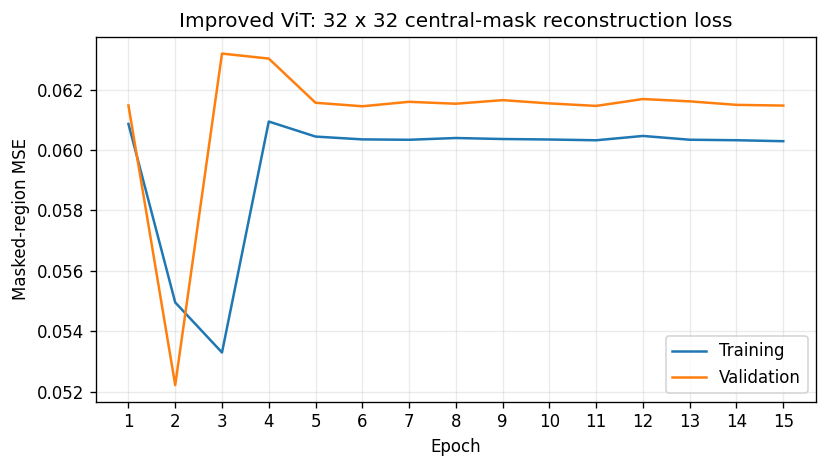

In [ ]:
epoch_numbers = range(1, len(improved_vit_train_losses) + 1)
fig, ax = plt.subplots(figsize=(7, 4), dpi=120)
ax.plot(epoch_numbers, improved_vit_train_losses, label='Training')
ax.plot(epoch_numbers, improved_vit_val_losses, label='Validation')
ax.set_title('Improved ViT: 32 x 32 central-mask reconstruction loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Masked-region MSE')
ax.set_xticks(list(epoch_numbers))
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

In [ ]:
improved_vit_validation_scores = {
    'Whole-image MSE': [],
    'Whole-image PSNR (dB)': [],
    'Whole-image SSIM': [],
    'Masked-region MSE': [],
    'Masked-region PSNR (dB)': [],
}
improved_vit_validation_examples = []
improved_vit.eval()
with torch.no_grad():
    for targets, _ in val_loader:
        targets = targets.to(DEVICE)
        masked_inputs, masks = make_training_inputs(targets)
        predictions = improved_vit(masked_inputs)
        reconstructions = reconstruct_images(masked_inputs, predictions, masks)

        assert reconstructions.shape == (targets.shape[0], 3, IMAGE_SIZE, IMAGE_SIZE)
        assert torch.isfinite(reconstructions).all().item()
        assert 0.0 <= reconstructions.min().item() <= reconstructions.max().item() <= 1.0
        visible_channels = (~masks).expand_as(targets)
        assert torch.equal(reconstructions[visible_channels], targets[visible_channels])

        for target, masked_input, reconstruction, mask in zip(
            targets, masked_inputs, reconstructions, masks
        ):
            for name, value in reconstruction_metrics(target, reconstruction, mask).items():
                improved_vit_validation_scores[name].append(value)

            if len(improved_vit_validation_examples) < 5:
                improved_vit_validation_examples.append((
                    target.cpu().clone(), masked_input.cpu().clone(), reconstruction.cpu().clone()
                ))

assert len(improved_vit_validation_scores['Whole-image MSE']) == len(val_loader.dataset)
improved_vit_validation_metrics = {
    name: float(np.mean(values)) for name, values in improved_vit_validation_scores.items()
}
# The restored model's masked MSE should match its best epoch's validation loss.
assert np.isclose(improved_vit_validation_metrics['Masked-region MSE'], best_improved_vit_val_loss, rtol=1e-4, atol=1e-7)
print(f'Improved ViT validation | best epoch {best_improved_vit_epoch} | 32 x 32 central masks')
for name, value in improved_vit_validation_metrics.items():
    print(f'{name}: {value:.6f}')
print('Reconstruction shape, range, and visible-pixel checks passed.')

assert len(improved_vit_validation_examples) == len(initial_vit_validation_examples)
for improved_example, initial_example in zip(improved_vit_validation_examples, initial_vit_validation_examples):
    assert torch.equal(improved_example[0], initial_example[0])
    assert torch.equal(improved_example[1], initial_example[1])
print('Initial and improved ViT examples use the same validation images and masks.')

Improved ViT validation | best epoch 2 | 32 x 32 central masks
Whole-image MSE: 0.003263
Whole-image PSNR (dB): 25.736396
Whole-image SSIM: 0.935920
Masked-region MSE: 0.052215
Masked-region PSNR (dB): 13.695196
Reconstruction shape, range, and visible-pixel checks passed.
Initial and improved ViT examples use the same validation images and masks.


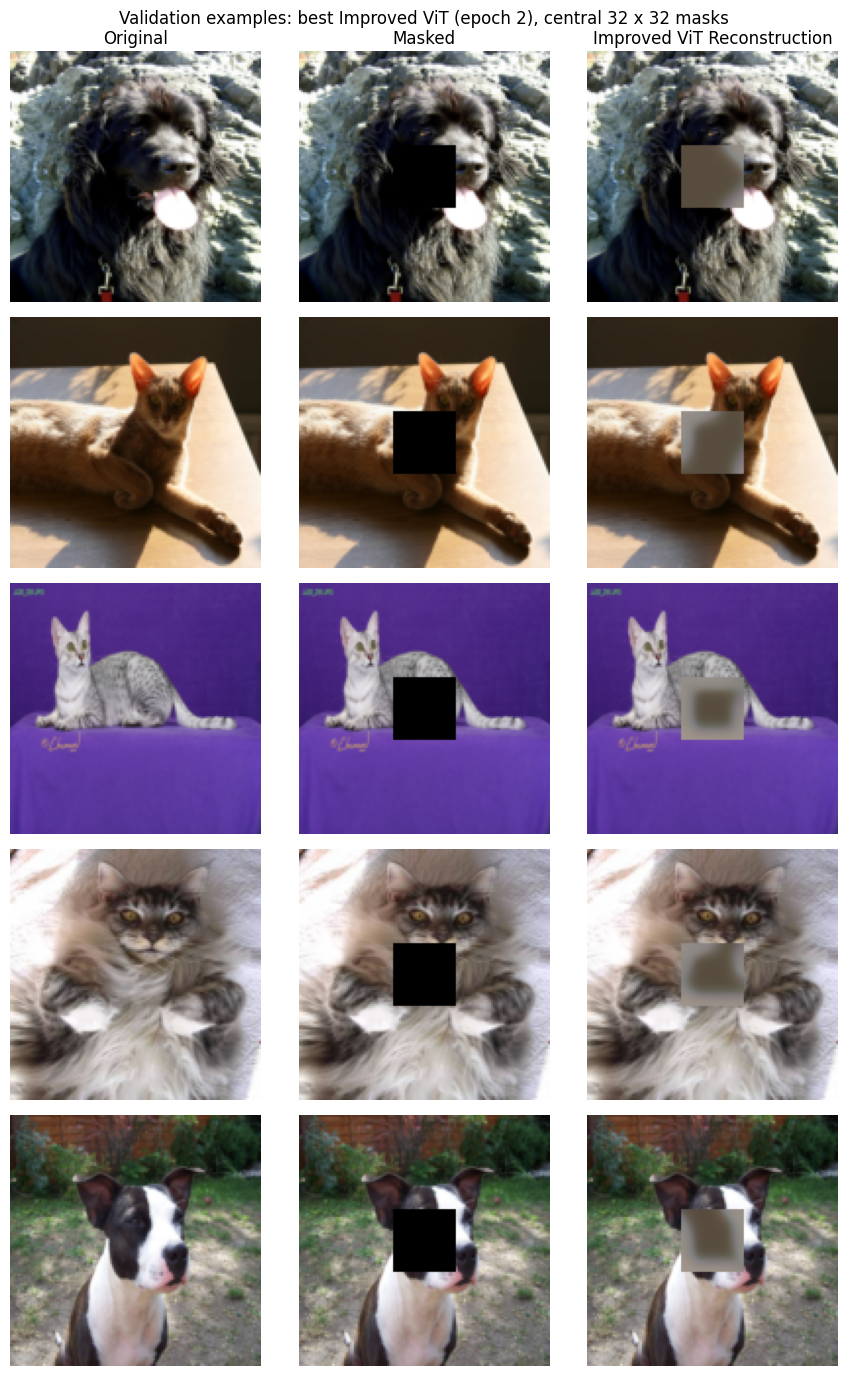

In [ ]:
fig, axes = plt.subplots(len(improved_vit_validation_examples), 3, figsize=(9, 14), squeeze=False)
for row, example in enumerate(improved_vit_validation_examples):
    for column, image in enumerate(example):
        axes[row, column].imshow(image.permute(1, 2, 0).numpy())
        axes[row, column].axis('off')
for ax, title in zip(axes[0], ('Original', 'Masked', 'Improved ViT Reconstruction')):
    ax.set_title(title)
fig.suptitle(f'Validation examples: best Improved ViT (epoch {best_improved_vit_epoch}), central 32 x 32 masks')
plt.tight_layout()
plt.show()

In [ ]:
# Read the existing initial results; do not retrain or reevaluate the initial ViT.
vit_improvement_comparison = pd.DataFrame.from_dict({
    'Initial ViT (16 x 16 patches)': initial_vit_validation_metrics,
    'Improved ViT (8 x 8 patches)': improved_vit_validation_metrics,
}, orient='index')
vit_improvement_comparison.index.name = 'Model'
print('Validation only: 32 x 32 central masks')
print(f'Initial best epoch: {initial_vit_best_epoch} | Improved best epoch: {best_improved_vit_epoch}')
display(vit_improvement_comparison.round(6))

Validation only: 32 x 32 central masks
Initial best epoch: 14 | Improved best epoch: 2


,Whole-image MSE,Whole-image PSNR (dB),Whole-image SSIM,Masked-region MSE,Masked-region PSNR (dB)
Model,,,,,
Initial ViT (16 x 16 patches),0.003780,25.020292,0.933219,0.060476,12.979092
Improved ViT (8 x 8 patches),0.003263,25.736396,0.935920,0.052215,13.695196


### Inspect spatial detail after training

The next figure enlarges the same 32 x 32 missing regions for the original, initial ViT, and improved ViT. Compare edges, texture, and spatial variation against the target, not just average color. Bilinear upsampling may smooth patch boundaries without recovering true structure, so smoother output alone is not evidence of improved reconstruction. Record conclusions only after inspecting the trained outputs and validation metrics.

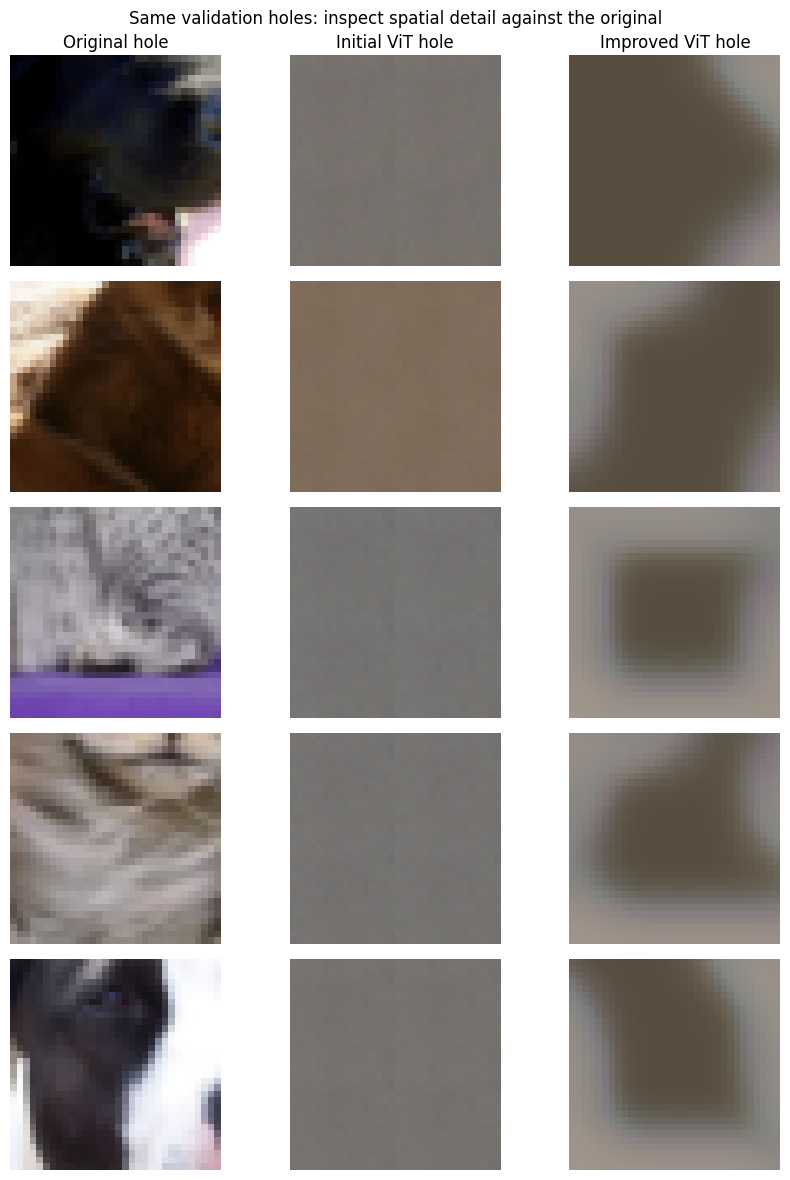

In [ ]:
hole_top = (IMAGE_SIZE - TRAIN_MASK_SIZE) // 2
hole_left = (IMAGE_SIZE - TRAIN_MASK_SIZE) // 2
fig, axes = plt.subplots(len(improved_vit_validation_examples), 3, figsize=(9, 12), squeeze=False)
for row, (initial_example, improved_example) in enumerate(zip(
    initial_vit_validation_examples, improved_vit_validation_examples
)):
    for column, image in enumerate((initial_example[0], initial_example[2], improved_example[2])):
        crop = image[:, hole_top:hole_top + TRAIN_MASK_SIZE, hole_left:hole_left + TRAIN_MASK_SIZE]
        axes[row, column].imshow(crop.permute(1, 2, 0).numpy(), interpolation='nearest')
        axes[row, column].axis('off')
for ax, title in zip(axes[0], ('Original hole', 'Initial ViT hole', 'Improved ViT hole')):
    ax.set_title(title)
fig.suptitle('Same validation holes: inspect spatial detail against the original')
plt.tight_layout()
plt.show()

### Phase 6B measured results (completed Colab run)

The 15-epoch AdamW run used learning rate 0.001, weight decay 0.01, batch size 32, and the existing train/validation splits with 32 x 32 central masks. The model has **684,963 trainable parameters** and **256 patch tokens**. Outputs above were captured from the completed Colab run; weights remain in that runtime's memory.

| Validation metric | Initial ViT | Improved ViT |
|---|---:|---:|
| Whole-image MSE | 0.003780 | 0.003263 |
| Whole-image PSNR (dB) | 25.020292 | 25.736396 |
| Whole-image SSIM | 0.933219 | 0.935920 |
| Masked-region MSE | 0.060476 | 0.052215 |
| Masked-region PSNR (dB) | 12.979092 | 13.695196 |
| Best epoch | 14 | 2 |

Masked-region MSE decreased by approximately **13.7%**. The improved model adds coarse spatial variation and smoother transitions compared with the initial nearly uniform predictions, but the five inspected holes remain blurry and do not reliably recover edges or fine texture. This is a modest improvement, not a resolution of the spatial-detail problem. Validation loss worsened after epoch 2 and stayed near 0.0615, so the restored early checkpoint is essential. These are validation results only; neither the test set nor an ensemble was used.


## Phase 7: U-Net + improved ViT ensemble (validation only)

An ensemble may help when the models make different reconstruction errors. We average their RGB predictions as `alpha * unet_prediction + (1 - alpha) * improved_vit_prediction`, then use the existing reconstruction helper to insert predictions **only inside the missing region**. Visible input pixels remain unchanged.

Use the **best-validation U-Net and improved ViT** in evaluation mode, without changing their weights or training them. Test only alpha values **0.25, 0.50, and 0.75**, corresponding to 25%, 50%, and 75% U-Net contribution. All comparisons use the existing validation split, 32 x 32 central masks, and shared metric functions.

Select the alpha with the **lowest validation masked-region MSE** and record it as `SELECTED_ENSEMBLE_ALPHA` for the later, frozen test protocol. Selecting on validation rather than test data keeps the test set independent of model selection. The best of these three ensembles may still perform worse than an individual model; the table and printed comparisons will show the actual result.

Run this section in the existing Colab session after Phases 4 and 6B, with both best models still in memory. No earlier training cells need to be rerun. The five qualitative examples use the same validation originals and masks as before.

In [ ]:
ENSEMBLE_ALPHAS = (0.25, 0.50, 0.75)
assert IMAGE_SIZE == 128 and TRAIN_MASK_SIZE == 32

# Verify that the already-restored models are the saved best-validation models.
# These checks do not load or alter weights.
for name, parameter in unet.state_dict().items():
    assert torch.equal(parameter.detach().cpu(), best_unet_state[name].cpu()), 'U-Net is not at its best validation state.'
for name, parameter in improved_vit.state_dict().items():
    assert torch.equal(parameter.detach().cpu(), best_improved_vit_state[name].cpu()), 'Improved ViT is not at its best validation state.'
unet.eval()
improved_vit.eval()

print(f'U-Net best epoch: {best_unet_epoch} | Improved ViT best epoch: {best_improved_vit_epoch}')
print(f'Validation images: {len(val_loader.dataset)} | Central mask: {TRAIN_MASK_SIZE} x {TRAIN_MASK_SIZE}')
print(f'Alpha candidates (U-Net weight): {ENSEMBLE_ALPHAS}')

U-Net best epoch: 15 | Improved ViT best epoch: 2
Validation images: 736 | Central mask: 32 x 32
Alpha candidates (U-Net weight): (0.25, 0.5, 0.75)


In [ ]:
# Evaluate both individual models and all three weights in a single validation pass.
# Each model runs once per batch; only the small weighted average varies with alpha.
ensemble_labels = {alpha: f'Ensemble alpha = {alpha:.2f}' for alpha in ENSEMBLE_ALPHAS}
phase7_model_names = ['U-Net', 'Improved ViT', *ensemble_labels.values()]
phase7_scores = {
    model_name: {metric: [] for metric in unet_validation_metrics}
    for model_name in phase7_model_names
}
phase7_examples = []

with torch.no_grad():
    for targets, _ in val_loader:
        targets = targets.to(DEVICE)
        masked_inputs, masks = make_training_inputs(targets)
        unet_prediction = unet(masked_inputs)
        improved_vit_prediction = improved_vit(masked_inputs)
        phase7_predictions = {
            'U-Net': unet_prediction,
            'Improved ViT': improved_vit_prediction,
        }
        for alpha in ENSEMBLE_ALPHAS:
            phase7_predictions[ensemble_labels[alpha]] = (
                alpha * unet_prediction + (1 - alpha) * improved_vit_prediction
            )

        phase7_reconstructions = {}
        for model_name, prediction in phase7_predictions.items():
            reconstruction = reconstruct_images(masked_inputs, prediction, masks)
            assert reconstruction.shape == (targets.shape[0], 3, IMAGE_SIZE, IMAGE_SIZE)
            assert torch.isfinite(reconstruction).all().item()
            assert 0.0 <= reconstruction.min().item() <= reconstruction.max().item() <= 1.0
            visible_channels = (~masks).expand_as(targets)
            assert torch.equal(reconstruction[visible_channels], masked_inputs[visible_channels])
            phase7_reconstructions[model_name] = reconstruction
            for target, image, mask in zip(targets, reconstruction, masks):
                for metric, value in reconstruction_metrics(target, image, mask).items():
                    phase7_scores[model_name][metric].append(value)

        # Cache only the first five examples, including all three candidate ensembles.
        for index in range(min(targets.shape[0], 5 - len(phase7_examples))):
            phase7_examples.append({
                'Original': targets[index].cpu().clone(),
                'Masked': masked_inputs[index].cpu().clone(),
                **{name: batch[index].cpu().clone() for name, batch in phase7_reconstructions.items()},
            })

for scores in phase7_scores.values():
    assert all(len(values) == len(val_loader.dataset) for values in scores.values())
phase7_validation_metrics = {
    model_name: {metric: float(np.mean(values)) for metric, values in scores.items()}
    for model_name, scores in phase7_scores.items()
}

# Check that the individual-model results still agree with previous evaluations.
for model_name, stored_metrics in (
    ('U-Net', unet_validation_metrics), ('Improved ViT', improved_vit_validation_metrics)
):
    for metric, stored_value in stored_metrics.items():
        assert np.isclose(phase7_validation_metrics[model_name][metric], stored_value, rtol=1e-4, atol=1e-7)
assert len(phase7_examples) == len(unet_validation_examples)
for example, earlier_example in zip(phase7_examples, unet_validation_examples):
    assert torch.equal(example['Original'], earlier_example[0])
    assert torch.equal(example['Masked'], earlier_example[1])
print('Validation complete: all five approaches evaluated; shapes, ranges, visible pixels, and matching examples verified.')

Validation complete: all five approaches evaluated; shapes, ranges, visible pixels, and matching examples verified.


In [ ]:
# Select using full-precision mean masked-region MSE, not rounded table values.
SELECTED_ENSEMBLE_ALPHA = min(
    ENSEMBLE_ALPHAS,
    key=lambda alpha: phase7_validation_metrics[ensemble_labels[alpha]]['Masked-region MSE'],
)
selected_ensemble_label = ensemble_labels[SELECTED_ENSEMBLE_ALPHA]
selected_ensemble_metrics = dict(phase7_validation_metrics[selected_ensemble_label])

ensemble_validation_comparison = pd.DataFrame.from_dict(phase7_validation_metrics, orient='index')
ensemble_validation_comparison.index.name = 'Model'
ensemble_validation_comparison['Selected ensemble'] = [
    'Yes' if name == selected_ensemble_label else '' for name in ensemble_validation_comparison.index
]
print(f'SELECTED_ENSEMBLE_ALPHA = {SELECTED_ENSEMBLE_ALPHA:.2f}')
print(f'{SELECTED_ENSEMBLE_ALPHA:.0%} U-Net + {1 - SELECTED_ENSEMBLE_ALPHA:.0%} improved ViT')
print('Record this alpha for later frozen test evaluation; no test data used here.')
display(ensemble_validation_comparison.round(6))

for individual_name in ('U-Net', 'Improved ViT'):
    difference = selected_ensemble_metrics['Masked-region MSE'] - phase7_validation_metrics[individual_name]['Masked-region MSE']
    outcome = 'lower (better)' if difference < 0 else 'higher (worse)' if difference > 0 else 'equal'
    print(f'Selected ensemble masked MSE vs {individual_name}: {outcome}; difference = {difference:+.6f}')

SELECTED_ENSEMBLE_ALPHA = 0.75
75% U-Net + 25% improved ViT
Validation selection only; keep this alpha fixed for later test evaluation.


,Whole-image MSE,Whole-image PSNR (dB),Whole-image SSIM,Masked-region MSE,Masked-region PSNR (dB),Selected ensemble
Model,,,,,,
U-Net,0.001341,29.790144,0.957640,0.021456,17.748944,
Improved ViT,0.003263,25.736396,0.935920,0.052215,13.695196,
Ensemble alpha = 0.25,0.002426,26.974214,0.942055,0.038823,14.933014,
Ensemble alpha = 0.50,0.001827,28.186634,0.948331,0.029233,16.145434,
Ensemble alpha = 0.75,0.001465,29.221079,0.954066,0.023444,17.179879,Yes


Selected ensemble masked MSE vs U-Net: higher (worse); difference = +0.001988
Selected ensemble masked MSE vs Improved ViT: lower (better); difference = -0.028771


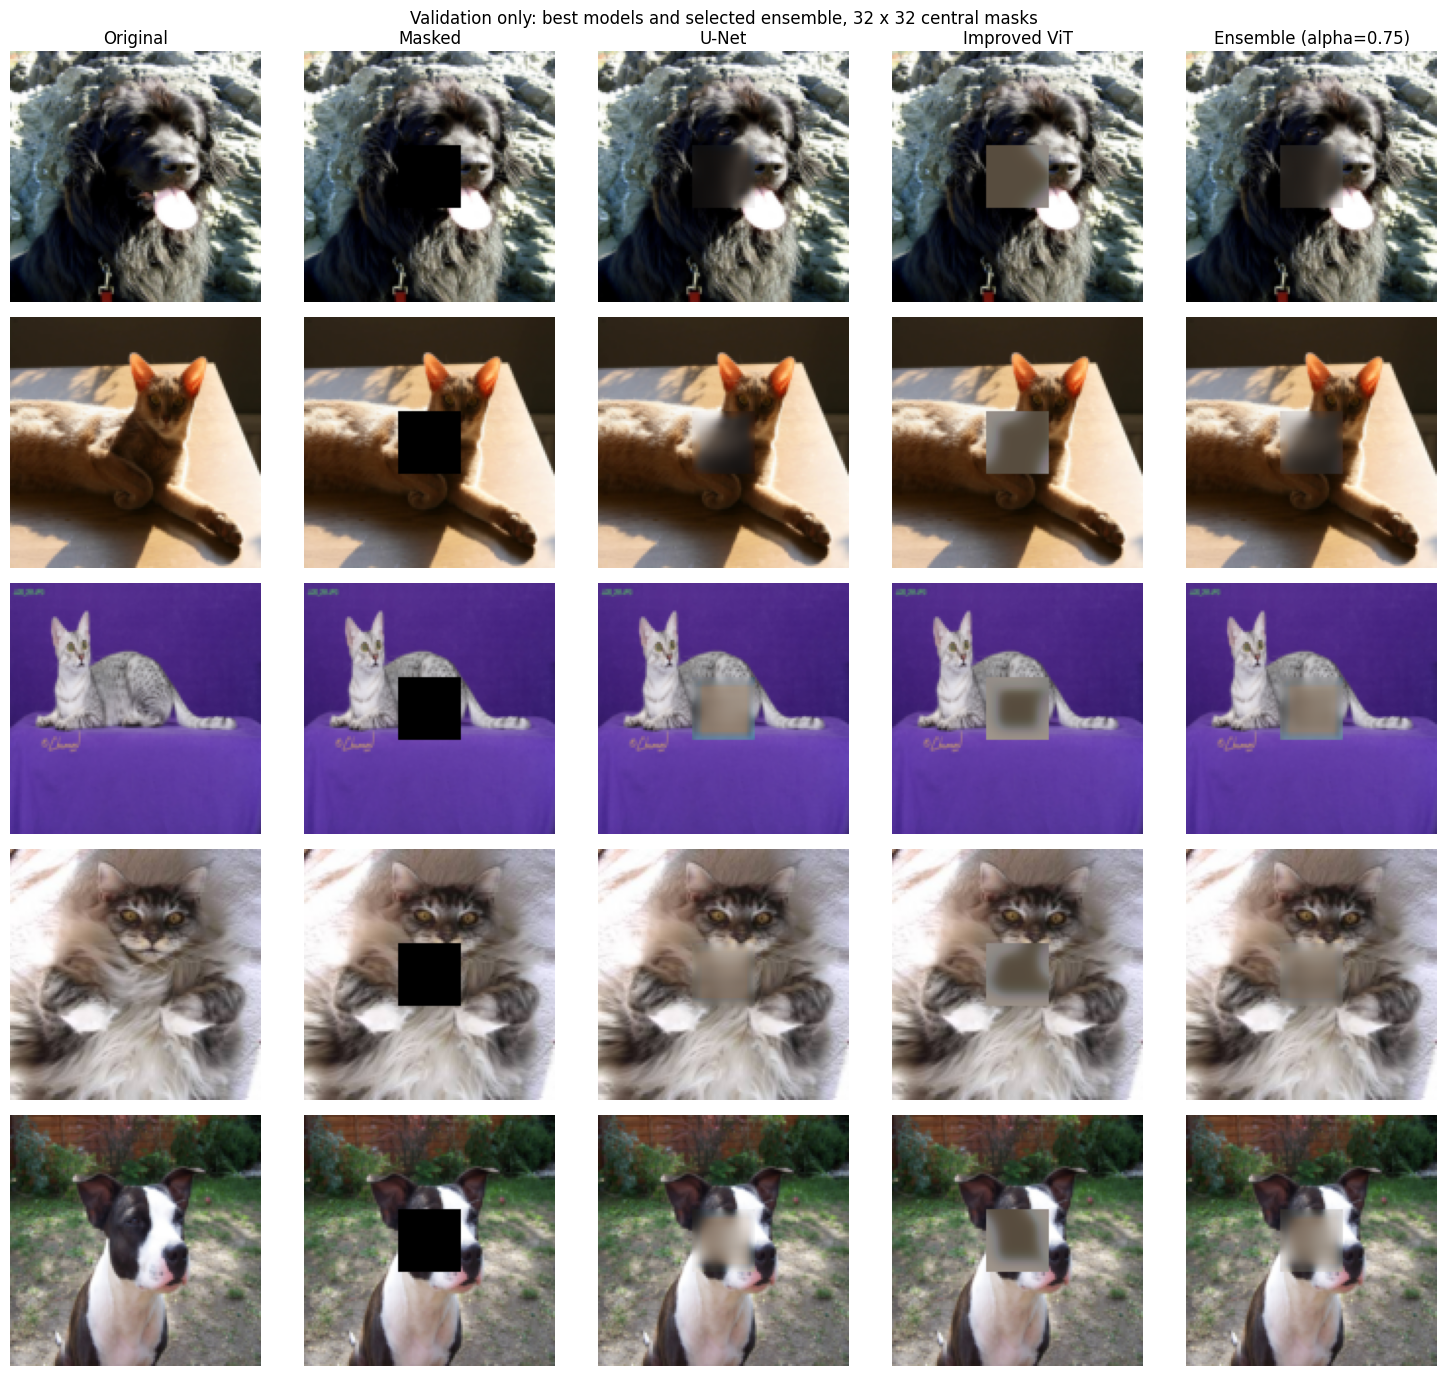

In [ ]:
phase7_columns = ['Original', 'Masked', 'U-Net', 'Improved ViT', selected_ensemble_label]
fig, axes = plt.subplots(len(phase7_examples), 5, figsize=(15, 14), squeeze=False)
for row, example in enumerate(phase7_examples):
    for column, name in enumerate(phase7_columns):
        axes[row, column].imshow(example[name].permute(1, 2, 0).numpy())
        axes[row, column].axis('off')
for ax, title in zip(axes[0], ('Original', 'Masked', 'U-Net', 'Improved ViT', f'Ensemble (alpha={SELECTED_ENSEMBLE_ALPHA:.2f})')):
    ax.set_title(title)
fig.suptitle('Validation only: best models and selected ensemble, 32 x 32 central masks')
plt.tight_layout()
plt.show()

### Phase 7 measured validation results

The selected weight is **`SELECTED_ENSEMBLE_ALPHA = 0.75`**, meaning **75% U-Net + 25% improved ViT**. Selection used the lowest full-precision validation masked-region MSE among the three requested weights on all 736 validation images. Keep this alpha fixed for later test evaluation.

| Model | MSE | PSNR (dB) | SSIM | Masked MSE | Masked PSNR (dB) |
|---|---:|---:|---:|---:|---:|
| U-Net | 0.001341 | 29.790144 | 0.957640 | 0.021456 | 17.748944 |
| Improved ViT | 0.003263 | 25.736396 | 0.935920 | 0.052215 | 13.695196 |
| Ensemble alpha = 0.25 | 0.002426 | 26.974214 | 0.942055 | 0.038823 | 14.933014 |
| Ensemble alpha = 0.50 | 0.001827 | 28.186634 | 0.948331 | 0.029233 | 16.145434 |
| **Ensemble alpha = 0.75 (selected)** | **0.001465** | **29.221079** | **0.954066** | **0.023444** | **17.179879** |

The selected ensemble improves on improved ViT but **does not improve on U-Net**: masked MSE is 0.023444 versus 0.021456 (approximately 9.3% higher). None of the three ensemble weights outperformed U-Net on validation masked MSE. The figure shows the ensemble remains close to U-Net with some smoothing from the ViT; it does not recover fine detail reliably. This is a validation observation, not the final test comparison.

Both models matched their saved best-validation weights before evaluation (U-Net epoch 15; improved ViT epoch 2). All reconstruction checks passed, including unchanged visible pixels and matching validation examples. No weights were updated, no architectures were changed, and no test or robustness experiment was run.

To reproduce in the current Colab runtime, run only the Phase 7 code cells (52-55); the trained models, best-state copies, helpers, and validation data must still be in memory. Saved outputs document this run but do not contain model weights.
